In [7]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent
movies_feature_file = ROOT / "data" / "features" / "movies_features.csv"
df = pd.read_csv(movies_feature_file)

print("Shape:", df.shape)

Shape: (2963, 30)


In [8]:
df.columns.tolist()

['movie_id',
 'title',
 'overview',
 'release_date',
 'runtime',
 'original_language',
 'genres',
 'keywords',
 'budget',
 'revenue',
 'popularity',
 'vote_average',
 'vote_count',
 'tagline',
 'status',
 'adult',
 'production_companies',
 'production_countries',
 'belongs_to_collection',
 'poster_path',
 'backdrop_path',
 'release_year',
 'release_month',
 'release_decade',
 'roi',
 'movie_age',
 'genre_count',
 'keyword_count',
 'runtime_category',
 'overview_length']

In [9]:
threshold = df["vote_count"].median()

df["high_engagement"] = (df["vote_count"] >= threshold).astype(int)

print("threshold:", threshold)
print("\ncounts")
print(df["high_engagement"].value_counts())
print("\nproportions")
print(df["high_engagement"].value_counts(normalize=True))

threshold: 3284.0

counts
high_engagement
1    1482
0    1481
Name: count, dtype: int64

proportions
high_engagement
1    0.500169
0    0.499831
Name: proportion, dtype: float64


In [10]:
# vote_count est volontairement absent : il a servi à créer la cible.
num_features = [
    "runtime",
    "budget",
    "revenue",
    "vote_average",
    "release_year",
    "release_month",
    "release_decade",
    "genre_count",
    "keyword_count",
    "roi",
    "movie_age",
    "overview_length"
]

categorical_features = [
    "original_language",
    "status",
    "runtime_category"
]

lists_columns = [
    "genres",
    "keywords"
]

In [11]:
import ast

def parse_names(value):
    if pd.isna(value):
        return []
    try:
        items = ast.literal_eval(value) if isinstance(value, str) else value
        return [item["name"] for item in items if isinstance(item, dict) and "name" in item]
    except (ValueError, SyntaxError, TypeError):
        return []

df["genres"] = df["genres"].apply(lambda value: " , ".join(parse_names(value)) or "no_genre")
df["keywords"] = df["keywords"].apply(lambda value: " ".join(parse_names(value)))

features = num_features + categorical_features + lists_columns

In [12]:
X = df[features]
y = df["high_engagement"]

print("X:", X.shape)
print("y:", y.shape)
print("\nmissing values")
print(X.isna().sum())

X: (2963, 17)
y: (2963,)

missing values
runtime               33
budget               546
revenue              510
vote_average           0
release_year           3
release_month          3
release_decade         3
genre_count            0
keyword_count          0
roi                  621
movie_age              3
overview_length        0
original_language      0
status                 0
runtime_category      33
genres                 0
keywords               0
dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2370, 17)
X_test: (593, 17)
y_train: (2370,)
y_test: (593,)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessor, num_features),
    ("categorical", categorical_preprocessor, categorical_features),
    ("genres", CountVectorizer(binary=True, token_pattern=r"[^,]+"), "genres"),
    ("keywords", TfidfVectorizer(max_features=5000, ngram_range=(1, 2)), "keywords"),
])

### 1. Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)
y_score_logistic = logistic_model.predict_proba(X_test)[:, 1]

### 2. Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_score_rf = random_forest_model.predict_proba(X_test)[:, 1]

### 3. Linear SVM

In [17]:
from sklearn.svm import LinearSVC

linear_svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearSVC(
        random_state=42,
        max_iter=5000
    ))
])

linear_svm_model.fit(X_train, y_train)

y_pred_svm = linear_svm_model.predict(X_test)
y_score_svm = linear_svm_model.decision_function(X_test)

### Évaluation des 3 modèles

On mesure :
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score)
    }

results = {
    "Logistic Regression": evaluate_model(
        y_test, y_pred_logistic, y_score_logistic
    ),
    "Random Forest": evaluate_model(
        y_test, y_pred_rf, y_score_rf
    ),
    "Linear SVM": evaluate_model(
        y_test, y_pred_svm, y_score_svm
    )
}

results_df = pd.DataFrame(results).T
results_df.sort_values("F1-score", ascending=False)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Random Forest,0.809444,0.782209,0.858586,0.818620,0.901413
Logistic Regression,0.757167,0.782288,0.713805,0.746479,0.852057
Linear SVM,0.752108,0.765957,0.727273,0.746114,0.834243


### Matrices de confusion

the matrics allow the visualisation of :TN, FP, FN, TP

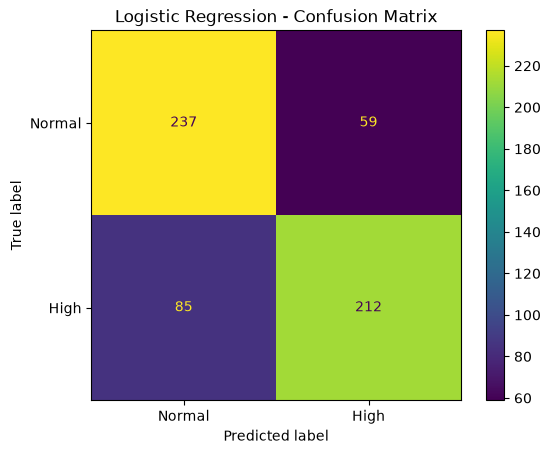

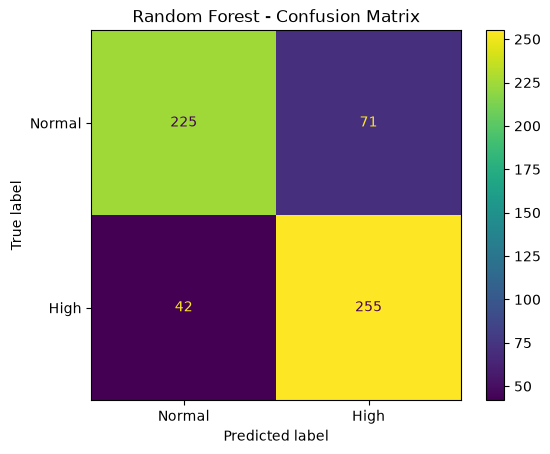

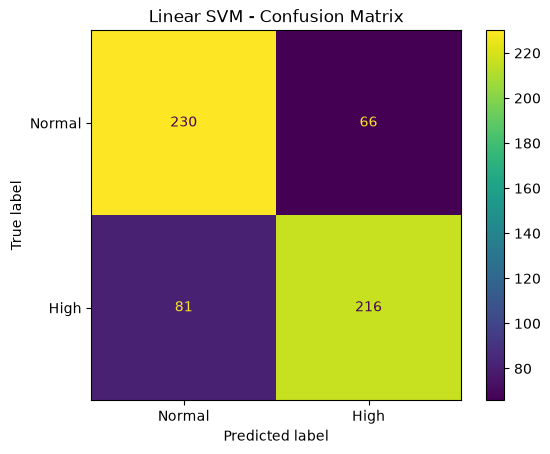

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Random Forest": y_pred_rf,
    "Linear SVM": y_pred_svm
}

for model_name, y_pred in models_predictions.items():
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Normal", "High"]
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

### Classification reports

In [20]:
from sklearn.metrics import classification_report

for model_name, y_pred in models_predictions.items():
    print(f"========== {model_name} ===========")
    print(
        classification_report( 
            y_test,
            y_pred,
            target_names=["Normal engagement", "High engagement"],
            zero_division=0
        )
    )

========== Logistic Regression ===========
                   precision    recall  f1-score   support

Normal engagement       0.74      0.80      0.77       296
  High engagement       0.78      0.71      0.75       297

         accuracy                           0.76       593
        macro avg       0.76      0.76      0.76       593
     weighted avg       0.76      0.76      0.76       593

========== Random Forest ===========
                   precision    recall  f1-score   support

Normal engagement       0.84      0.76      0.80       296
  High engagement       0.78      0.86      0.82       297

         accuracy                           0.81       593
        macro avg       0.81      0.81      0.81       593
     weighted avg       0.81      0.81      0.81       593

========== Linear SVM ===========
                   precision    recall  f1-score   support

Normal engagement       0.74      0.78      0.76       296
  High engagement       0.77      0.73      0.75     

### Conclusion
the three models are trained with a pipeline contains the imputation and standarization.
based on the results the best model is RandomForest

# Validation et optimisation #

### 1- cross-validation

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

In [22]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [23]:
models = {
    "Logistic Regression": logistic_model,
    "SVM": linear_svm_model,
    "Random Forest": random_forest_model
}

cv_results = {}

for name, model in models.items():
    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )

    cv_results[name] = results

    print(f"\n{name}")
    print(f"Accuracy : {results['test_accuracy'].mean():.4f}")
    print(f"Precision: {results['test_precision'].mean():.4f}")
    print(f"Recall   : {results['test_recall'].mean():.4f}")
    print(f"F1       : {results['test_f1'].mean():.4f}")
    print(f"ROC-AUC  : {results['test_roc_auc'].mean():.4f}")


Logistic Regression
Accuracy : 0.7996
Precision: 0.8088
Recall   : 0.7857
F1       : 0.7965
ROC-AUC  : 0.8871

SVM
Accuracy : 0.7949
Precision: 0.7971
Recall   : 0.7916
F1       : 0.7939
ROC-AUC  : 0.8662

Random Forest
Accuracy : 0.8414
Precision: 0.8183
Recall   : 0.8785
F1       : 0.8469
ROC-AUC  : 0.9226


### 2- GridSearchCV

In [24]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

In [25]:
grid_search = GridSearchCV(
    random_forest_model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support 

In [26]:
print("Best parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Best CV F1: 0.8506101193697718


### 3- Compare before vs after optimization

In [27]:
rf_cv = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

before_f1 = rf_cv["test_score"].mean()
after_f1 = grid_search.best_score_

print(f"Before optimization: {before_f1:.4f}")
print(f"After optimization : {after_f1:.4f}")

improvement = after_f1 - before_f1
print(f"Improvement: {improvement:.4f}")

Before optimization: 0.8469
After optimization : 0.8506
Improvement: 0.0037


In [28]:
import joblib

best_model = grid_search.best_estimator_

joblib.dump(
    best_model,
    ROOT / "models" / "random_forest_best.joblib"
)

['/home/elgmouri/projects/moviesHub/models/random_forest_best.joblib']